# Tutorial 01 — Explore the derivative-faithfulness diagnostic

This notebook is a **hands-on tour of the current headline science** in this repo:
a *derivative-faithfulness diagnostic* for PySR symbolic equations distilled from
the PRIYA Lyman-alpha P1D Gaussian-process (GP) emulator.

**What you'll do here is 100% emulator-free.** We only read CSV files that are
already committed to the repo (`results/.../refit/z3.6/`). No GP, no Julia, no
PySR run is needed — everything below loads from `pandas`.

### The one idea to take away

A symbolic equation can fit the emulator's *values* almost perfectly and still be
**useless for a Fisher forecast**, because a Fisher forecast only uses the
equation's *slope* `dP/dtheta`, not its value. The diagnostic scores the slope.
We call a value-accurate but slope-wrong equation **"Fisher's Mirage."**

> Background, in order of depth: `HANDOFF.md` (TL;DR) ->
> `docs/PARETO_FAITHFULNESS_WALKTHROUGH.md` (the source-of-truth writeup).


## 0. Setup

We need the `priya_forecast` package on the path. The repo convention is
`PYTHONPATH=src`; here we just locate the repo root and add `src/` to
`sys.path` so the notebook runs from anywhere.

Only three third-party deps are touched: `numpy`, `pandas`, `matplotlib`. The
diagnostic modules (`pareto_diag`, `grad_faith_io`) are pure-Python plotting/IO —
they do **not** import GPy or the emulator.


In [1]:
import sys
from pathlib import Path

# Find the repo root by walking up until we see the `src/priya_forecast` package.
here = Path.cwd()
ROOT = next(
    (p for p in [here, *here.parents] if (p / "src" / "priya_forecast").is_dir()),
    None,
)
assert ROOT is not None, "Run this notebook from inside the lya1d_priya_forecast repo."
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)

import numpy as np
import pandas as pd

from priya_forecast.pareto_diag import load_front, render_grid, GATE_TOL
from priya_forecast.grad_faith_io import read_grad_faith_sidecar
from priya_forecast.parameters import PARAM_NAMES

print("GATE_TOL =", GATE_TOL)
print("parameters:", list(PARAM_NAMES))

repo root: /home/mfho/lya1d_priya_forecast


GATE_TOL = 0.25
parameters: ['dtau0', 'tau0', 'ns', 'Ap', 'herei', 'heref', 'alphaq', 'hub', 'omegamh2', 'hireionz', 'bhfeedback']


## 1. The two files that describe one parameter

For each of the 11 forecast parameters and each redshift, a PySR run produces a
**Pareto front** of candidate equations, saved as `pareto_<param>.csv`. Alongside
it we cache a **grad-faith sidecar**, `grad_faith_<param>.csv`, that scores each
candidate against the GP.

We'll use the **Sobolev-trained** `z=3.6` run as our working example, and the
parameter `ns` (the primordial spectral index) — it's the star of the Mirage
story.


In [2]:
SOBOLEV = ROOT / "results/single_z_stage9/refit/z3.6"      # derivative-matching (Sobolev) loss
VALUE   = ROOT / "results/single_z_stage6_log/refit/z3.6"  # plain value (log-P MSE) loss

pareto_csv  = SOBOLEV / "pareto_ns.csv"
sidecar_csv = SOBOLEV / "grad_faith_ns.csv"
print("pareto :", pareto_csv.relative_to(ROOT))
print("sidecar:", sidecar_csv.relative_to(ROOT))
assert pareto_csv.exists() and sidecar_csv.exists()

pareto : results/single_z_stage9/refit/z3.6/pareto_ns.csv
sidecar: results/single_z_stage9/refit/z3.6/grad_faith_ns.csv


### 1a. The Pareto CSV — raw PySR output

This is exactly what PySR writes. Each row is one candidate equation, trading
**complexity** (number of nodes) against **Loss** (the PySR *training* loss).

Columns:
- `Complexity` — equation size (node count). Bigger = more expressive.
- `Loss` — PySR's internal training loss. **Not comparable across runs** trained
  with different objectives (a value-MSE run and a Sobolev run print losses on
  different scales).
- `Equation` — the symbolic expression in PySR's notation. `x0` is the parameter
  being varied (e.g. `ns`); `x1, x2, ...` are other features (e.g. `k`).
- `score`, `sympy_format`, `lambda_format` — PySR bookkeeping / a callable form.


In [3]:
pareto = pd.read_csv(pareto_csv)
print(pareto.shape)
pareto[["Complexity", "Loss", "Equation"]]

(16, 6)


,Complexity,Loss,Equation
0,1,71.146330,-0.7480067
1,2,67.879840,square(x0)
2,3,65.445560,x1 * x0
3,4,61.911780,x1 * exp(x0)
4,5,55.015500,x1 * (x0 * 4.7702484)
5,7,47.824757,x0 * ((x1 * 7.6515665) + -1.575237)
6,8,42.724876,square(log(square((x0 + x1) + 0.5232912)))
7,9,38.829613,square(x0 - square(0.8757557 - x1)) * 3.2105234
8,10,29.508842,(3.7070765 - square(square(square(1.2908324 - ...
9,11,24.440790,square(square(square(square(1.022214 - x1))) -...


Notice the equations get richer as complexity climbs: from a constant
(`-0.748`), to `square(x0)`, to `x1 * exp(x0)`, up to multi-term expressions that
use a custom operator `aq(...)`. PySR found these; we did not hand-write them.


### 1b. The grad-faith sidecar — the emulator-grounded scorecard

The sidecar pairs **1:1** with the Pareto CSV but only keeps *Fisher-safe*
candidates and adds the columns that actually matter for a forecast. The first
line is a `#` provenance header (param / z / tol / log_space / source); the loader
skips it.


In [4]:
# Peek at the raw header line, then load it properly.
with open(sidecar_csv) as fh:
    print("header:", fh.readline().rstrip())

side = read_grad_faith_sidecar(sidecar_csv)   # skips the '#' comment for you
side

header: # param=ns z=3.6 tol=0.25 log_space=True source=results/single_z_stage9/refit/z3.6/pareto_ns.csv


,Complexity,Loss,grad_err,value_mse,n_keep,gate_pass,x0_enters
0,18,11.323040,0.193431,0.000474,48,True,True
1,16,11.857336,0.276076,0.000560,48,False,True
2,15,12.880447,0.275270,0.001419,48,False,True
3,14,13.189540,0.474145,0.000845,48,False,True
4,13,16.807730,0.375871,0.000407,48,False,True
5,12,16.860823,0.404138,0.000450,48,False,True
6,11,24.440790,0.451653,0.004922,48,False,True
7,10,29.508842,0.370700,0.006502,48,False,True
8,9,38.829613,0.653660,0.003462,48,False,True
9,8,42.724876,0.294375,0.004544,48,False,True


**The columns, decoded:**

| column | meaning |
|---|---|
| `Complexity` | matches a row in the Pareto CSV (the join key) |
| `Loss` | the PySR training loss, copied over |
| **`grad_err`** | **the headline metric.** `median_k \| (dP_F^eq/dtheta) / (dP_F^GP/dtheta) - 1 \|` at the fiducial point, in **linear** P_F. I.e. the median fractional error of the equation's *slope* vs the GP's slope, across k-bins. **Lower is better; 0 = perfect slope.** |
| **`value_mse`** | a *common* value loss: `mean (logP_eq - logP_GP)^2` over a (theta x k) grid. Unlike `Loss`, this **is** comparable across runs, so it's the honest y-axis when you overlay a value-run and a Sobolev-run. |
| `n_keep` | number of (theta, k) eval points used |
| **`gate_pass`** | `grad_err <= 0.25`. `True` = the equation is **faithful** = trustworthy for Fisher. |
| `x0_enters` | does the equation actually use the parameter feature `x0`? (a sanity check — an equation that drops `x0` has zero slope and is meaningless for that parameter) |

The `0.25` gate is a deliberately loose, fixed tolerance: a 25% error on a Fisher
derivative is roughly the line below which the resulting parameter error bar is
not materially distorted. It lives in code as `GATE_TOL`.


In [5]:
print("GATE_TOL =", GATE_TOL)
print("\nfraction of candidates that pass the gate:",
      f"{side['gate_pass'].mean():.0%}")
print("best (lowest-Loss) candidate grad_err:",
      f"{side.sort_values('Loss').iloc[0]['grad_err']:.3f}")

GATE_TOL = 0.25

fraction of candidates that pass the gate: 7%
best (lowest-Loss) candidate grad_err: 0.193


## 2. `grad_err` vs `value_mse` — the Mirage in one table

Here's the crux. Let's look at the candidates that have **small value error** and
ask whether they also have **small slope error**. Sort by `value_mse` (best value
fit first) and eyeball `grad_err`.


In [6]:
look = side[["Complexity", "value_mse", "grad_err", "gate_pass"]].copy()
look = look.sort_values("value_mse").reset_index(drop=True)
look

,Complexity,value_mse,grad_err,gate_pass
0,13,0.000407,0.375871,False
1,12,0.000450,0.404138,False
2,18,0.000474,0.193431,True
3,16,0.000560,0.276076,False
4,14,0.000845,0.474145,False
5,15,0.001419,0.275270,False
6,3,0.002637,0.946573,False
7,2,0.003244,0.511977,False
8,9,0.003462,0.653660,False
9,4,0.004433,0.888360,False


Read down the `grad_err` column: several candidates with tiny `value_mse`
(excellent value fits) still have `grad_err` well above 0.25 and **fail the gate**.
That is Fisher's Mirage — *value accuracy does not imply slope accuracy.*

Only the candidates whose `gate_pass == True` are safe to put into a Fisher matrix.


In [7]:
passing = side[side["gate_pass"] == True]
print(f"{len(passing)} of {len(side)} ns candidates clear the 0.25 gate.")
passing[["Complexity", "value_mse", "grad_err"]]

1 of 15 ns candidates clear the 0.25 gate.


,Complexity,value_mse,grad_err
0,18,0.000474,0.193431


## 3. `load_front` — the convenience joiner

You rarely merge the two CSVs by hand. `priya_forecast.pareto_diag.load_front`
does the left-join for you and returns a tidy frame with exactly the columns the
plotter needs: `Complexity, Loss, grad_err, gate_pass, value_mse`.

Key behaviour: it's a **left join on the full Pareto front**, so rows that exist in
the Pareto CSV but have *no* sidecar entry (e.g. a candidate that dropped `x0`, or
a too-trivial constant) come back with `grad_err = NaN`. Those are the "we couldn't
score this" candidates, drawn gray later.


In [8]:
front = load_front(pareto_csv, sidecar_csv)
print("columns:", list(front.columns))
print(f"{front['grad_err'].isna().sum()} of {len(front)} Pareto rows have no sidecar score (NaN).")
front

columns: ['Complexity', 'Loss', 'grad_err', 'gate_pass', 'value_mse']
1 of 16 Pareto rows have no sidecar score (NaN).


,Complexity,Loss,grad_err,gate_pass,value_mse
0,1,71.146330,NaN,NaN,NaN
1,2,67.879840,0.511977,False,0.003244
2,3,65.445560,0.946573,False,0.002637
3,4,61.911780,0.888360,False,0.004433
4,5,55.015500,0.770896,False,0.005835
5,7,47.824757,0.625163,False,0.005885
6,8,42.724876,0.294375,False,0.004544
7,9,38.829613,0.653660,False,0.003462
8,10,29.508842,0.370700,False,0.006502
9,11,24.440790,0.451653,False,0.004922


You can also call `load_front(pareto_csv)` with **no sidecar** — every score
comes back `NaN`. That's the "value-only" mode used while iterating layout before
the (GP-dependent) gradient eval has been computed on the cluster.


In [9]:
value_only = load_front(pareto_csv)        # no sidecar argument
print("all grad_err NaN?", value_only["grad_err"].isna().all())
value_only.head(3)

all grad_err NaN? True


,Complexity,Loss,grad_err,gate_pass,value_mse
0,1,71.14633,NaN,<NA>,NaN
1,2,67.87984,NaN,<NA>,NaN
2,3,65.44556,NaN,<NA>,NaN


## 4. `render_grid` — drawing the diagnostic panels

`render_grid` plots one panel per parameter. On each panel:

- **x-axis** = complexity, **y-axis** (log) = `value_mse` (or `Loss`).
- **colour** = `grad_err` on a red->yellow->green scale centered on the gate
  (`TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=1)`): **green = faithful, red = Mirage.**
- **marker edge encodes the gate:** a **bold black ring** = clears the 0.25 gate;
  a thin grey edge = fails; a grey *fill* = couldn't be scored (NaN).

The input is a dict `{param: [ {front, label, marker}, ... ]}`, so you can overlay
several runs (e.g. value-trained circles vs Sobolev-trained squares) on the same
panel.

### 4a. A single panel for `ns`


wrote /home/mfho/lya1d_priya_forecast/results/_tutorial_scratch/ns_panel.png


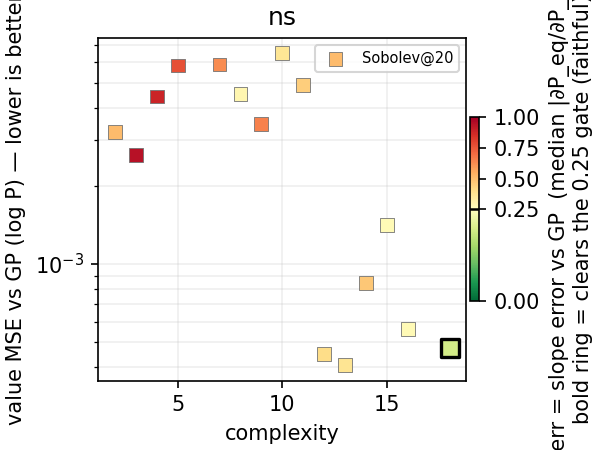

In [10]:
out_dir = ROOT / "results" / "_tutorial_scratch"
out_dir.mkdir(parents=True, exist_ok=True)

panel = render_grid(
    {"ns": [{"front": front, "label": "Sobolev@20", "marker": "s"}]},
    out_dir / "ns_panel.png",
    y_col="value_mse",
    y_label="value MSE vs GP (log P) — lower is better",
    ncol=1,
)
print("wrote", panel)

from IPython.display import Image
Image(filename=str(panel))

Greener points = faithful slope. The bold-ringed green points near the top
(highest complexity) are the ones a forecast can trust; the small red points lower
down are low-value-error Mirages.


### 4b. The money plot: value loss vs Sobolev loss, side by side

Now overlay the **value-trained** run (circles, from `single_z_stage6_log`) and the
**Sobolev-trained** run (squares, from `single_z_stage9`) for `ns`. This reproduces
the headline result in miniature: plain value training leaves `ns` red (Mirage),
and the derivative-matching Sobolev loss turns it green (cured).


ns best grad_err  (value loss)   : 0.834  -> FAIL (Mirage)
ns best grad_err  (Sobolev loss) : 0.376  -> FAIL (Mirage)


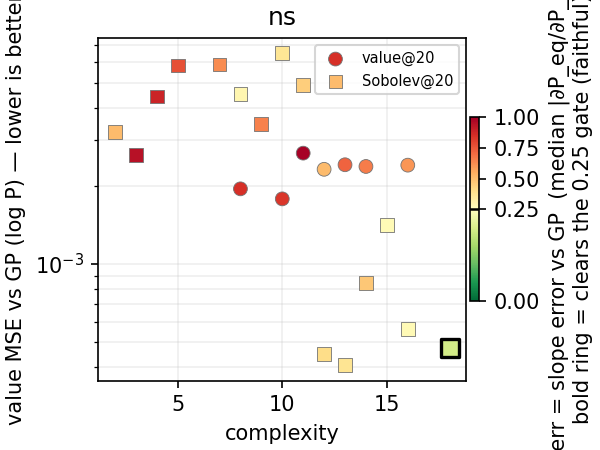

In [11]:
ns_value   = load_front(VALUE / "pareto_ns.csv",   VALUE / "grad_faith_ns.csv")
ns_sobolev = load_front(SOBOLEV / "pareto_ns.csv", SOBOLEV / "grad_faith_ns.csv")

def best_grad_err(df):
    scored = df.dropna(subset=["grad_err"])
    return scored.sort_values("value_mse").iloc[0]["grad_err"]

print(f"ns best grad_err  (value loss)   : {best_grad_err(ns_value):.3f}  "
      f"-> {'PASS' if best_grad_err(ns_value) <= GATE_TOL else 'FAIL (Mirage)'}")
print(f"ns best grad_err  (Sobolev loss) : {best_grad_err(ns_sobolev):.3f}  "
      f"-> {'PASS' if best_grad_err(ns_sobolev) <= GATE_TOL else 'FAIL (Mirage)'}")

money = render_grid(
    {"ns": [
        {"front": ns_value,   "label": "value@20",   "marker": "o"},
        {"front": ns_sobolev, "label": "Sobolev@20", "marker": "s"},
    ]},
    out_dir / "ns_money.png",
    y_col="value_mse",
    y_label="value MSE vs GP (log P) — lower is better",
    ncol=1,
)
Image(filename=str(money))

That ~0.60 -> ~0.19 drop in `ns` slope error, achieved with **comparable
value error**, is the core evidence that the Sobolev derivative-matching loss is
the cure for the Mirage — not just a smaller search or a better value fit.


## 5. Contrast: a parameter that's faithful no matter what

Not every parameter is a Mirage. `dtau0` (the mean-flux / optical-depth scaling)
is *robustly faithful*: even simple, value-trained equations get the slope right.
Let's confirm by loading its sidecar directly.


In [12]:
dtau0 = read_grad_faith_sidecar(SOBOLEV / "grad_faith_dtau0.csv")
print("dtau0 best grad_err:", f"{dtau0.sort_values('Loss').iloc[0]['grad_err']:.3f}")
print("dtau0 fraction passing gate:", f"{dtau0['gate_pass'].mean():.0%}")
dtau0[["Complexity", "value_mse", "grad_err", "gate_pass"]].sort_values("value_mse").head(8)

dtau0 best grad_err: 0.003
dtau0 fraction passing gate: 86%


,Complexity,value_mse,grad_err,gate_pass
0,20,0.000003,0.002932,True
2,17,0.000003,0.003132,True
1,19,0.000003,0.002615,True
4,13,0.000003,0.008749,True
3,15,0.000003,0.008476,True
5,11,0.000004,0.007399,True
6,10,0.000011,0.004922,True
7,9,0.000023,0.013769,True


Almost everything is green here. The taxonomy from the full study (see
`HANDOFF.md`) sorts the 11 parameters into: *robustly faithful* (e.g. `dtau0`,
`tau0`, `heref`, `alphaq`, `hireionz`), *selection-sensitive* (`Ap`, `herei`,
`omegamh2`), *Mirage-cured-by-Sobolev* (`ns`), and *resistant* (`hub`,
`bhfeedback`).


### 5a. The whole grid at a glance (optional)

For completeness, here's how the production figure is assembled: build a
`fronts_by_param` dict over all 11 parameters and render the full grid. (This is a
trimmed version of `scripts/make_diagnostic_figs.py`.)


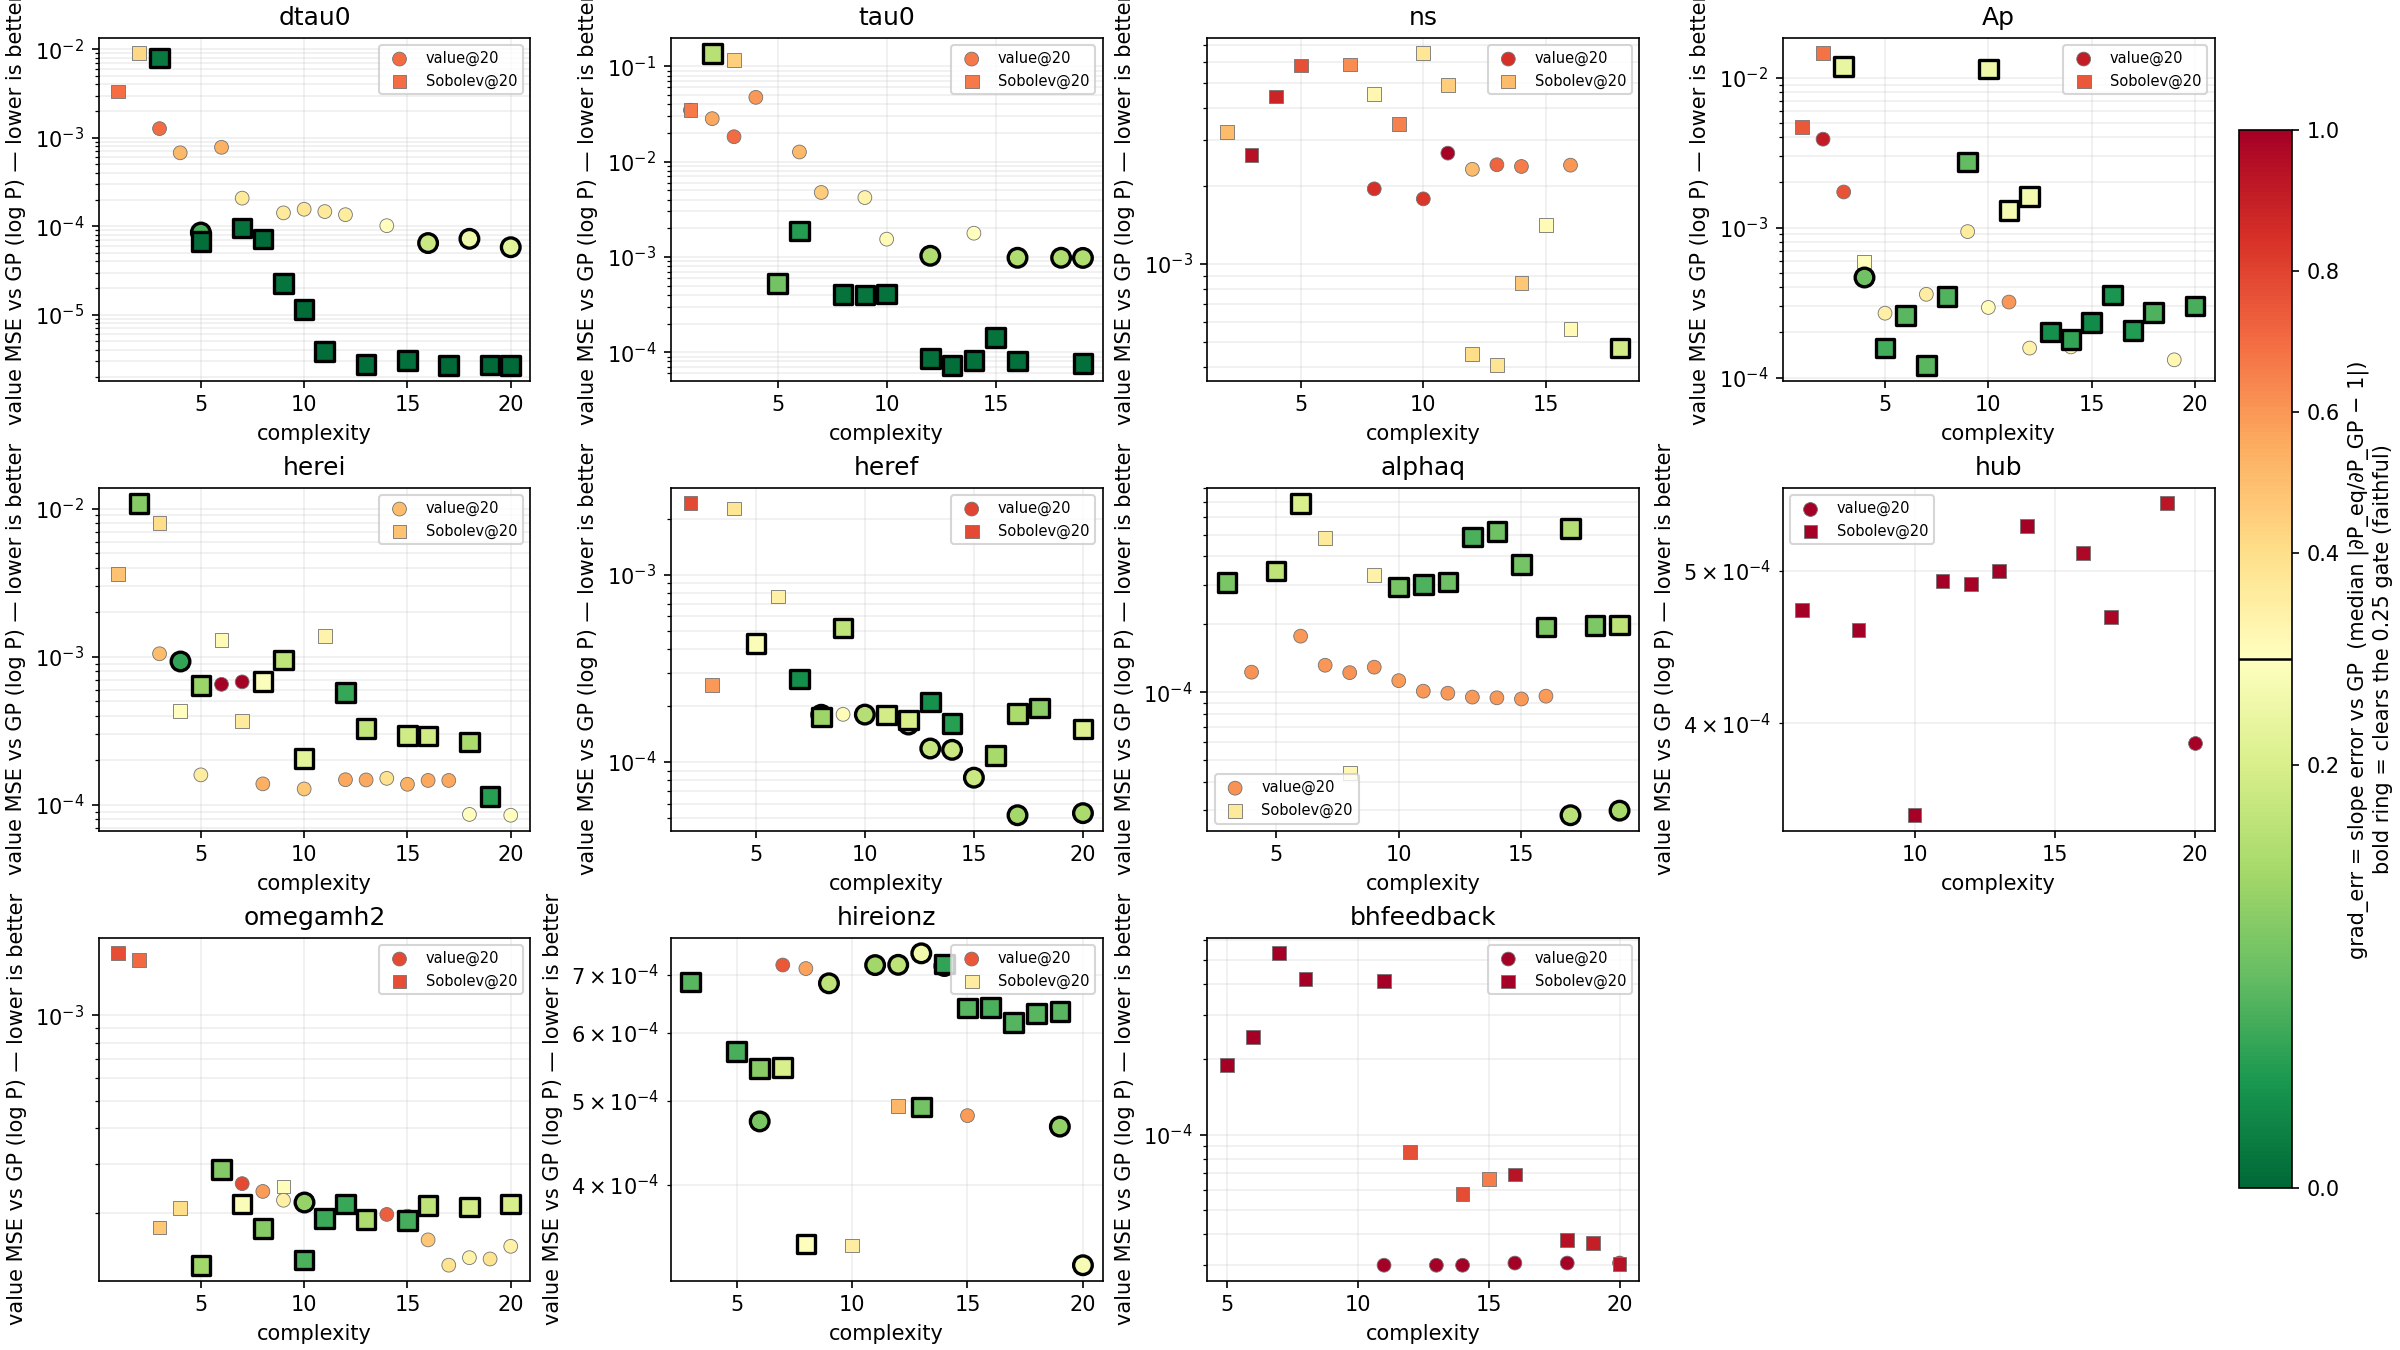

In [13]:
fronts = {}
for p in PARAM_NAMES:
    fronts[p] = [
        {"front": load_front(VALUE / f"pareto_{p}.csv",   VALUE / f"grad_faith_{p}.csv"),
         "label": "value@20",   "marker": "o"},
        {"front": load_front(SOBOLEV / f"pareto_{p}.csv", SOBOLEV / f"grad_faith_{p}.csv"),
         "label": "Sobolev@20", "marker": "s"},
    ]

grid = render_grid(
    fronts,
    out_dir / "grid_all_params.png",
    y_col="value_mse",
    y_label="value MSE vs GP (log P) — lower is better",
    param_order=list(PARAM_NAMES),
    ncol=4,
)
Image(filename=str(grid))

## 6. Scope caveat (important, honest framing)

The diagnostic measures the equation's slope **against the GP emulator's slope** —
i.e. the GP is treated as the *oracle*. So `grad_err` answers *"is the symbolic
equation a faithful surrogate for the GP's derivative?"*, **not** *"is the GP's
derivative itself correct vs the true physics?"* The forecast-grade
σ_PySR/σ_GP ratio that earlier drafts headlined was shown to be a forced Jacobian
identity (σ_perfect_1D ≡ σ_GP), which is why the project pivoted to this
**diagnostic / failure-modes** framing. See
`docs/PARETO_FAITHFULNESS_WALKTHROUGH.md` for the full argument.

### Where to go next
- `docs/PARETO_FAITHFULNESS_WALKTHROUGH.md` — the source-of-truth writeup.
- `scripts/make_diagnostic_figs.py` — regenerates the 3 paper figures, emulator-free
  (`PYTHONPATH=src python scripts/make_diagnostic_figs.py --out-dir results/single_z_stage_pareto_diag`).
- `scripts/eval_grad_faithfulness.py` — recomputes a sidecar from scratch
  (**this one needs the GP**).
- Other refit dirs under `results/` for cross-z runs (z=2.6 / 4.2) — the taxonomy
  is *not* redshift-uniform; the He II block degrades at z=4.2.

The scratch PNGs this notebook wrote live in `results/_tutorial_scratch/` and can
be deleted freely.
